In [1]:
import json
import os
from pathlib import Path
import sys

# Pandas may not be in requirements; fail with a clear message if missing
try:
    import pandas as pd
except Exception as e:
    raise ImportError(
        "pandas is required for this notebook. Install it with: pip install pandas"
    )

import matplotlib.pyplot as plt
%matplotlib inline

def find_results_dir():
    candidates = [
        Path.cwd() / 'engine-chess' / 'results',
        Path.cwd() / 'engine-chess',
        Path.cwd() / 'results',
        Path.cwd()
    ]
    for c in candidates:
        if (c / 'baseline_summary.json').exists() and (c / 'hybrid_summary.json').exists():
            return c
    # fallback: walk tree to find files
    for root, dirs, files in os.walk(Path.cwd()):
        if 'baseline_summary.json' in files and 'hybrid_summary.json' in files:
            return Path(root)
    raise FileNotFoundError('Could not locate results directory containing baseline_summary.json and hybrid_summary.json')

RESULTS_DIR = find_results_dir()
RESULTS_DIR

WindowsPath('c:/Users/MSI-GAMING/PKA/monte_dan_minimax(forked)/engine-chess/results')

In [2]:
# Load summaries
with open(RESULTS_DIR / 'baseline_summary.json', 'r', encoding='utf-8') as f:
    baseline = json.load(f)
with open(RESULTS_DIR / 'hybrid_summary.json', 'r', encoding='utf-8') as f:
    hybrid = json.load(f)

# Quick sanity checks
print('Loaded baseline keys:', list(baseline.keys()))
print('Loaded hybrid keys:', list(hybrid.keys()))

Loaded baseline keys: ['config', 'metrics']
Loaded hybrid keys: ['config', 'metrics']


In [3]:
# Build a human-friendly table from the summaries
def summary_to_row(name, data):
    conf = data.get('config', {})
    met = data.get('metrics', {})
    return {
        'System': name,
        'Depth': conf.get('depth'),
        'Rollouts': conf.get('rollout_count'),
        'Games': conf.get('n_games'),
        'WinRate': met.get('win_rate'),
        'AvgMoveTime_s': met.get('avg_move_time'),
        'StdMoveTime_s': met.get('std_move_time'),
        'AvgCP_Loss': met.get('avg_cp_loss'),
        'MoveMatchRate': met.get('move_match_rate'),
        'TotalMoves': met.get('total_moves'),
    }

rows = [
    summary_to_row('Baseline (Minimax)', baseline),
    summary_to_row('Hybrid (Minimax + MC)', hybrid),
]
df = pd.DataFrame(rows)
# Add percentage columns for nicer display
df['WinRate (%)'] = df['WinRate'] * 100
df['Match Rate (%)'] = df['MoveMatchRate'] * 100
display_cols = ['System', 'Depth', 'Rollouts', 'Games', 'WinRate (%)', 'AvgMoveTime_s', 'StdMoveTime_s', 'AvgCP_Loss', 'Match Rate (%)', 'TotalMoves']

from IPython.display import display
display(df[display_cols].style.format({
    'WinRate (%)': '{:.2f}',
    'AvgMoveTime_s': '{:.4f}',
    'StdMoveTime_s': '{:.4f}',
    'AvgCP_Loss': '{:.2f}',
    'Match Rate (%)': '{:.2f}',
}))

,System,Depth,Rollouts,Games,WinRate (%),AvgMoveTime_s,StdMoveTime_s,AvgCP_Loss,Match Rate (%),TotalMoves
0,Baseline (Minimax),3,30,2,0.00,0.0721,0.0580,797.60,36.00,25
1,Hybrid (Minimax + MC),3,10,2,0.00,15.4754,7.2578,354.25,9.38,32


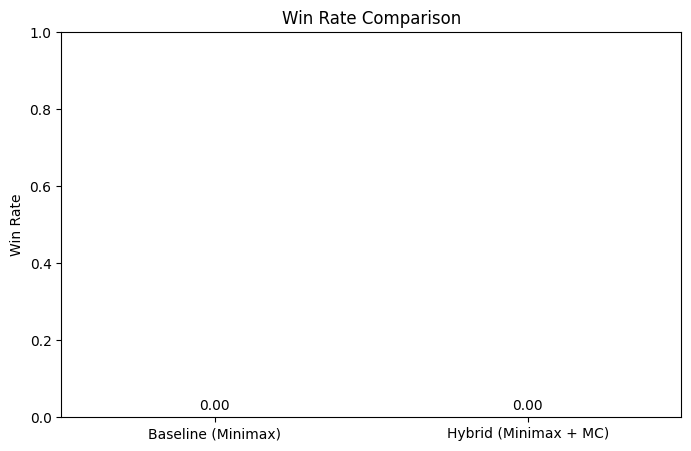

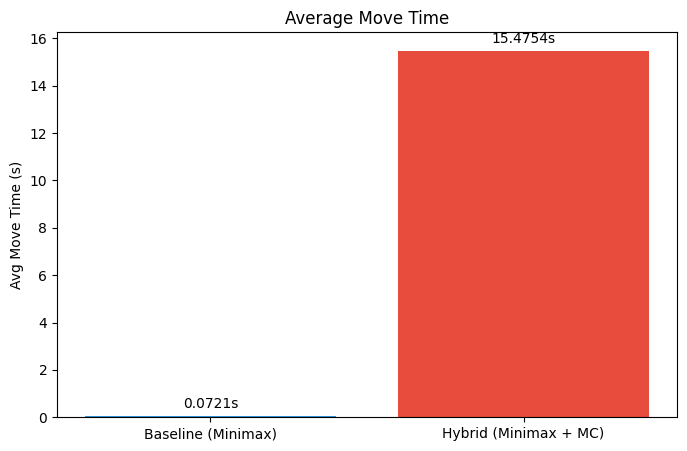

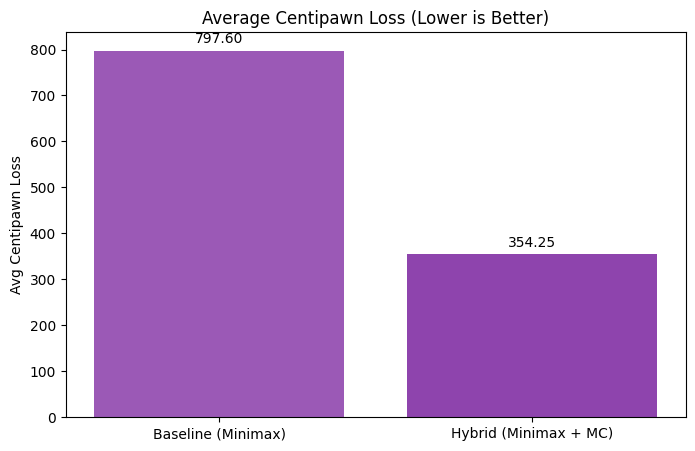

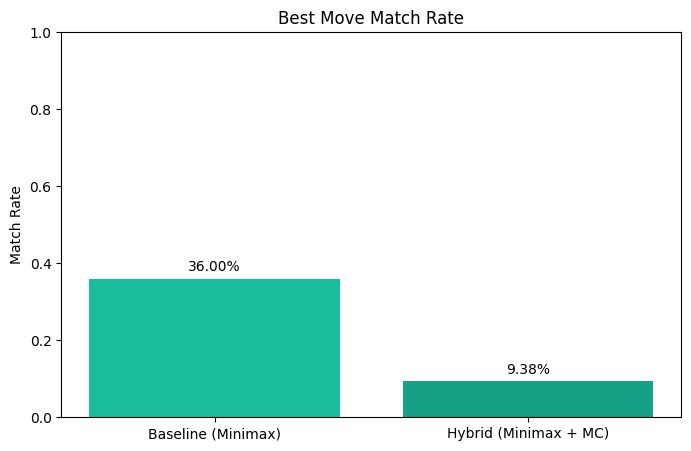

In [5]:
# Simple comparison plots (Win Rate, Move Time, CP Loss, Match Rate)
labels = df['System'].tolist()
x = range(len(labels))

plt.figure(figsize=(8, 5))
plt.bar(labels, df['WinRate'], color=['#2ecc71', '#f1c40f'])
plt.ylabel('Win Rate')
plt.ylim(0, 1.0)
plt.title('Win Rate Comparison')
for i, val in enumerate(df['WinRate']):
    plt.text(i, val + 0.02, f'{val:.2f}', ha='center')
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(labels, df['AvgMoveTime_s'], color=['#3498db', '#e74c3c'])
plt.ylabel('Avg Move Time (s)')
plt.title('Average Move Time')
for i, val in enumerate(df['AvgMoveTime_s']):
    plt.text(i, val + max(df['AvgMoveTime_s']) * 0.02, f'{val:.4f}s', ha='center')
plt.show()

if df['AvgCP_Loss'].notna().any():
    plt.figure(figsize=(8,5))
    plt.bar(labels, df['AvgCP_Loss'], color=['#9b59b6', '#8e44ad'])
    plt.ylabel('Avg Centipawn Loss')
    plt.title('Average Centipawn Loss (Lower is Better)')
    for i, val in enumerate(df['AvgCP_Loss']):
        plt.text(i, val + max(df['AvgCP_Loss']) * 0.02, f'{val:.2f}', ha='center')
    plt.show()

# Match rate as percentage
plt.figure(figsize=(8,5))
plt.bar(labels, df['Match Rate (%)'] / 100.0, color=['#1abc9c', '#16a085'])
plt.ylabel('Match Rate')
plt.title('Best Move Match Rate')
plt.ylim(0, 1.0)
for i, val in enumerate(df['Match Rate (%)'] / 100.0):
    plt.text(i, val + 0.02, f'{val:.2%}', ha='center')
plt.show()

---
**Catatan:** Notebook ini dibuat agar mudah dibaca dan dijalankan langsung dari folder `engine-chess/`. Jika Anda menjalankan notebook dari direktori lain dan mengalami masalah pencarian `results/`, jalankan ulang sel `find_results_dir()` atau ubah variabel `RESULTS_DIR` agar menunjuk ke folder `results` yang benar.